In [72]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from pathlib import Path
import os

In [98]:
def blur(img):

    img_float = np.array(img, dtype=np.float32)

    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols), np.float32)
    cv2.circle(mask, (ccol, crow), 70, 1, -1)
    mask = cv2.GaussianBlur(mask, (31, 31), 0)

    mask = cv2.merge([mask, mask])
    fshift = dft_shift * mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return img_back

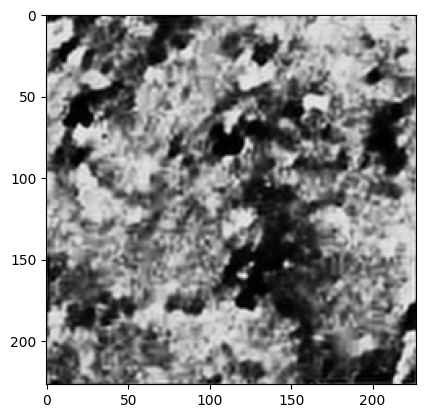

In [100]:

# def process_image(img):
img = cv2.imread("Negative/00002.jpg",cv2.IMREAD_GRAYSCALE)
equalizada = cv2.equalizeHist(img)


blurred_img = blur(equalizada)
plt.imshow(blurred_img, cmap='gray')

# binarizada = cv2.threshold(blurred_img, 127, 255, cv2.THRESH_BINARY_INV)[1]
# contour = cv2.Laplacian(binarizada, cv2.CV_64F)
# contour = cv2.normalize(contour, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# kernel = np.ones((3,3), np.uint8)
# fechamento = cv2.morphologyEx(binarizada, cv2.MORPH_CLOSE, kernel, iterations=7)
# return fechamento 
    




        

In [ ]:

pasta_negativa = "./Negative"         # onde estão os JPGs
pasta_positiva   = "./Positive"         # onde estão os JPGs

pasta_s_negativa = "./NegativaNovo"         # onde salvar os processados
pasta_s_positiva = "./PositivaNovo"         # onde salvar os processados

# 1. Criar pasta de saída se não existir
os.makedirs(pasta_s_negativa, exist_ok=True)
os.makedirs(pasta_s_positiva, exist_ok=True)

# 2. Listar todos os JPGs
paths1 = glob.glob(os.path.join(pasta_positiva, "*.jpg"))
i = 0
for p in paths1:
    if i == 500:
        break
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Falha ao ler:", p)
        continue
    processada = process_image(img)
    # 3. Montar nome de arquivo na pasta de saída
    nome = os.path.basename(p)                 # ex: "foto1.jpg"
    caminho_out = os.path.join(pasta_s_positiva, nome)

    # 4. Salvar a imagem (pode ser processada antes, se quiser)
    ok = cv2.imwrite(caminho_out, processada)
    if not ok:
        print("Falha ao salvar:", caminho_out)
    i+=1

paths2 = glob.glob(os.path.join(pasta_negativa, "*.jpg"))
i = 0
for p in paths2:
    if i == 500:
        break
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Falha ao ler:", p)
        continue
    processada = process_image(img)
    # 3. Montar nome de arquivo na pasta de saída
    nome = os.path.basename(p)                 # ex: "foto1.jpg"
    caminho_out = os.path.join(pasta_s_negativa, nome)

    # 4. Salvar a imagem (pode ser processada antes, se quiser)
    ok = cv2.imwrite(caminho_out, processada)
    if not ok:
        print("Falha ao salvar:", caminho_out)
    i+=1

<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarray'>
(227, 227)
<class 'numpy.ndarra

In [101]:
paths2 = glob.glob(os.path.join("Negative", "*.jpg"))
i = 0
for p in paths2:
    if i == 500:
        break
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Falha ao ler:", p)
        continue
    # 3. Montar nome de arquivo na pasta de saída
    nome = os.path.basename(p)                 # ex: "foto1.jpg"
    caminho_out = os.path.join("Neg", nome)

    # 4. Salvar a imagem (pode ser processada antes, se quiser)
    ok = cv2.imwrite(caminho_out, processada)
    if not ok:
        print("Falha ao salvar:", caminho_out)
    i+=1

Falha ao salvar: Neg\00001.jpg
Falha ao salvar: Neg\00002.jpg
Falha ao salvar: Neg\00003.jpg
Falha ao salvar: Neg\00004.jpg
Falha ao salvar: Neg\00005.jpg
Falha ao salvar: Neg\00006.jpg
Falha ao salvar: Neg\00007.jpg
Falha ao salvar: Neg\00008.jpg
Falha ao salvar: Neg\00009.jpg
Falha ao salvar: Neg\00010.jpg
Falha ao salvar: Neg\00011.jpg
Falha ao salvar: Neg\00012.jpg
Falha ao salvar: Neg\00013.jpg
Falha ao salvar: Neg\00014.jpg
Falha ao salvar: Neg\00015.jpg
Falha ao salvar: Neg\00016.jpg
Falha ao salvar: Neg\00017.jpg
Falha ao salvar: Neg\00018.jpg
Falha ao salvar: Neg\00019.jpg
Falha ao salvar: Neg\00020.jpg
Falha ao salvar: Neg\00021.jpg
Falha ao salvar: Neg\00022.jpg
Falha ao salvar: Neg\00023.jpg
Falha ao salvar: Neg\00024.jpg
Falha ao salvar: Neg\00025.jpg
Falha ao salvar: Neg\00026.jpg
Falha ao salvar: Neg\00027.jpg
Falha ao salvar: Neg\00028.jpg
Falha ao salvar: Neg\00029.jpg
Falha ao salvar: Neg\00030.jpg
Falha ao salvar: Neg\00031.jpg
Falha ao salvar: Neg\00032.jpg
Falha ao